# 人类 RefSeq mRNA 记录：长度与 GC 的分布特征

**一句话**：从 NCBI 公开取回 500 条人类 RefSeq mRNA 记录，清洗成可用表，用 4 张图回答「这批转录本在长度和碱基组成上有什么规律」。

**数据**：`w2/data/ncbi_raw.csv`（500 条记录，由 `w2/fetch_dataset.py` 拉取）+ `w2/data/gc_partial.csv`（其中 60 条的真实 GC 含量，由 `w2/add_gc.py` 计算）。

**出图规范**：仓根 `viz.py` 统一控制字体、配色、边框和导出 dpi —— 改一处，所有图一起变。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
if not (HERE / "data").exists():        # 从仓库根目录打开时
    HERE = HERE / "w2"
DATA, OUT = HERE / "data", HERE / "out"
OUT.mkdir(exist_ok=True)
sys.path.insert(0, str(HERE.parent))     # 让 `import viz` 生效

from viz import PALETTE, apply_style, save  # noqa: E402

apply_style()

## 1. 体检：这份表哪里不干净

In [2]:
raw = pd.read_csv(DATA / "ncbi_raw.csv")
print("形状:", raw.shape)
raw.head(3)

形状: (500, 7)


,accession,gene,length,moltype,organism,created,title
0,NM_000077.6,CDKN2A,1191,rna,Homo sapiens,1999/03/19,Homo sapiens cyclin dependent kinase inhibitor...
1,NM_001142769.4,PCDH15,5878,rna,Homo sapiens,2008/12/19,Homo sapiens protocadherin related 15 (PCDH15)...
2,NM_001441094.1,IQSEC2,5112,rna,Homo sapiens,2025/06/04,Homo sapiens IQ motif and Sec7 domain ArfGEF 2...


In [3]:
print("重复 accession:", raw["accession"].duplicated().sum())
print("gene 带尾缀的行数:", raw["gene"].str.contains(" ").sum())
print("gene 脏值示例:", list(raw.loc[raw["gene"].str.contains(" "), "gene"].unique()[:3]))
print("created 的类型:", type(raw["created"].iloc[0]).__name__, repr(raw["created"].iloc[0]))
print("moltype 取值:", list(raw["moltype"].unique()))

重复 accession: 0
gene 带尾缀的行数: 12
gene 脏值示例: ['ABCC1 blood group']
created 的类型: str '1999/03/19'
moltype 取值: ['rna']


## 2. 清洗：四步

1. `gene` 规范化：`ABCC1 blood group` → `ABCC1`
2. 日期转真日期 `datetime`，并派生出 `year`
3. 按 `accession` 去重、丢掉长度/年份缺失的行
4. 左连接 GC 表 —— **缺的留空，绝不填 0**

In [4]:
df = raw.copy()
df["gene"] = df["gene"].str.split().str[0].str.strip()
df["created"] = pd.to_datetime(df["created"], format="%Y/%m/%d", errors="coerce")
df["year"] = df["created"].dt.year
df = df.drop_duplicates(subset="accession").dropna(subset=["length", "year"])

gc = pd.read_csv(DATA / "gc_partial.csv")
df = df.merge(gc, on="accession", how="left")
sub = df.dropna(subset=["gc"])          # 只有要分析 GC 时才用这个子集

print(f"清洗后: {df.shape} | 有 GC: {sub.shape[0]} 条 | 缺 GC: {df.shape[0] - sub.shape[0]} 条")
print("缺失原因是没去拉序列（省请求），不是数据本身坏 —— 所以不能拿 0 或均值糊上去。")

清洗后: (500, 9) | 有 GC: 60 条 | 缺 GC: 440 条
缺失原因是没去拉序列（省请求），不是数据本身坏 —— 所以不能拿 0 或均值糊上去。


## 3. 四张图

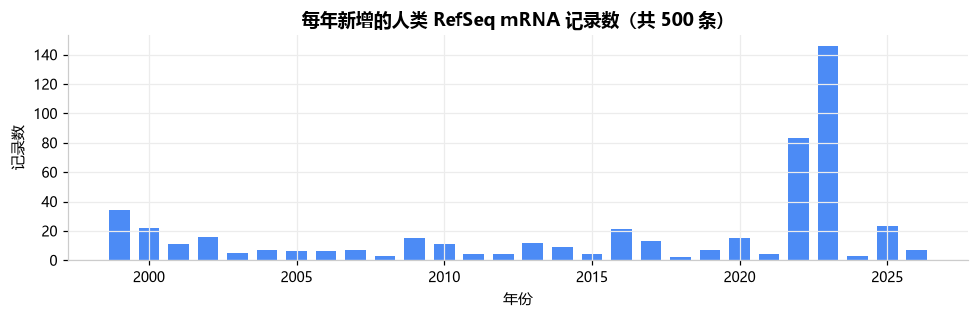

In [5]:
by_year = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.bar(by_year.index, by_year.values, color=PALETTE[0], width=0.7)
ax.set(title=f"每年新增的人类 RefSeq mRNA 记录数（共 {len(df)} 条）", xlabel="年份", ylabel="记录数")
save(fig, OUT / "fig1_by_year.png")
plt.show()

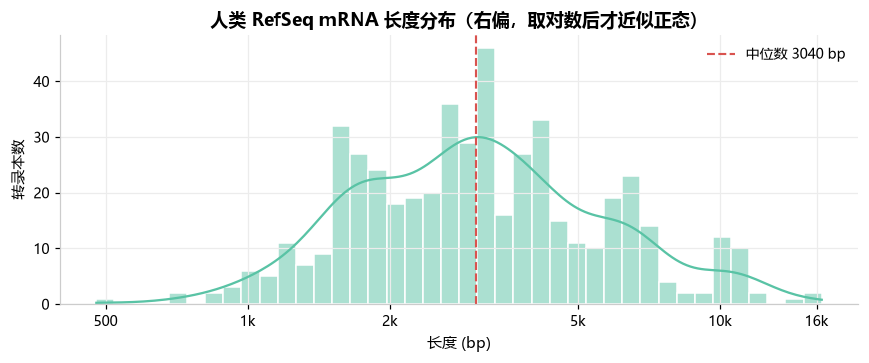

In [6]:
median_len = df["length"].median()
log_len = np.log10(df["length"])
ticks = [500, 1000, 2000, 5000, 10000, 16000]

fig, ax = plt.subplots(figsize=(8, 3.4))
sns.histplot(log_len, bins=40, color=PALETTE[1], edgecolor="white", kde=True, ax=ax)
ax.axvline(np.log10(median_len), color=PALETTE[4], ls="--", lw=1.4, label=f"中位数 {median_len:.0f} bp")
ax.set_xticks(np.log10(ticks))
ax.set_xticklabels([f"{t // 1000}k" if t >= 1000 else str(t) for t in ticks])
ax.set(title="人类 RefSeq mRNA 长度分布（右偏，取对数后才近似正态）",
       xlabel="长度 (bp)", ylabel="转录本数")
ax.legend()
save(fig, OUT / "fig2_length.png")
plt.show()

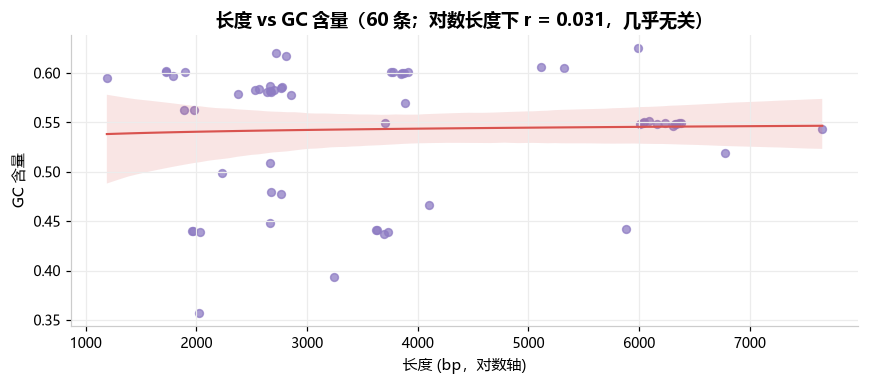

In [7]:
r = np.corrcoef(np.log10(sub["length"]), sub["gc"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 3.6))
sns.regplot(x=sub["length"], y=sub["gc"], ax=ax, logx=True,
            scatter_kws={"s": 26, "alpha": 0.75, "color": PALETTE[3]},
            line_kws={"color": PALETTE[4], "lw": 1.4})
ax.set(title=f"长度 vs GC 含量（{len(sub)} 条；对数长度下 r = {r:.3f}，几乎无关）",
       xlabel="长度 (bp，对数轴)", ylabel="GC 含量")
save(fig, OUT / "fig3_gc_length.png")
plt.show()

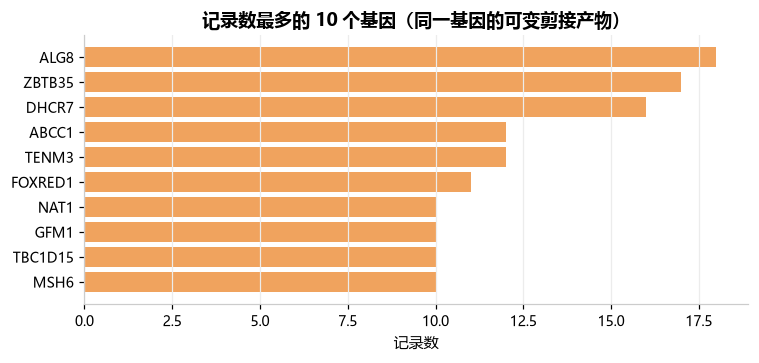

In [8]:
top = df["gene"].value_counts().head(10)[::-1]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(top.index, top.values, color=PALETTE[2])
ax.set(title="记录数最多的 10 个基因（同一基因的可变剪接产物）", xlabel="记录数", ylabel="")
ax.grid(axis="y", visible=False)
save(fig, OUT / "fig4_top_genes.png")
plt.show()

## 4. 能写进简历的数字

In [9]:
peak = df["year"].isin([2022, 2023]).mean()
print("记录数 / 覆盖基因:", len(df), "/", df["gene"].nunique())
print("长度: 中位 %.0f bp，范围 %d–%d bp" % (median_len, df["length"].min(), df["length"].max()))
print("GC: 中位 %.1f%%，范围 %.1f%%–%.1f%%" % (sub["gc"].median() * 100, sub["gc"].min() * 100, sub["gc"].max() * 100))
print("对数长度 vs GC 相关系数: %.3f" % r)
print("2022–2023 两年占全表: %.0f%%" % (peak * 100))
print("记录最多的 3 个基因:", list(df["gene"].value_counts().head(3).index))

记录数 / 覆盖基因: 500 / 142
长度: 中位 3040 bp，范围 478–16398 bp
GC: 中位 55.7%，范围 35.7%–62.5%
对数长度 vs GC 相关系数: 0.031
2022–2023 两年占全表: 46%
记录最多的 3 个基因: ['ALG8', 'ZBTB35', 'DHCR7']


### 结论

1. **不清洗就没法按基因统计**：500 条里有 12 行 `gene` 带尾缀（如 `ABCC1 blood group`）、日期是字符串、同一基因存在多个转录本；清洗后仍是 500 条，覆盖 **142 个基因**，记录最多的三个是 ALG8、ZBTB35、DHCR7 —— 那是同一基因的多条剪接变体，不是重复数据。

2. **记录数在 2022–2023 年集中爆发**（两年占全表 **46%**）。这不是生物学变化，而是 NCBI 批量重注释的产物 —— 看到异常先怀疑数据来源，别急着讲生物学故事。

3. **长度强烈右偏**：中位 **3040 bp**（478 – 16398 bp），取对数后才近似正态。面试里解释「为什么这里要用对数轴」比解释「怎么调颜色」有价值。

4. **GC 与长度基本无关**：60 条有 GC 的记录中位 **55.7%**（35.7% – 62.5%），对数长度下相关系数只有 **0.031**。GC 更像基因自身的特征，不是长度的函数。


### 局限与下一步

- **GC 只覆盖 60/500**：补全要 500 次请求，得遵守 NCBI ≤3 次/秒 的礼节（`w2/add_gc.py 500` 即可，约 3 分钟）。
- **样本是一个切片**：按发布日期取的前 500 条，不能外推到整个 RefSeq 库；要说「这 500 条里」，不说「人类 mRNA 都是」。
- **年份差异主要是注释行为**，不是基因变多变少。
- **下一步（W4+）**：把这类真实数据接进「生物医药文档问答助手」，让检索问答有真实语料支撑。